In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(
    "../data/raw/mental_health.csv"
)

df.head()

,text,status
0,i don't understand whats wrong with me. i don'...,Anxiety
1,usually when i have anxiety just chatting with...,Anxiety
2,"well, i've had anxiety and panic syndrome for ...",Anxiety
3,"for the most minimal of things, like standing ...",Anxiety
4,i stay away from family and live with my roomm...,Anxiety


In [3]:
print("Shape:",df.shape)

print("\nColumns:")

print(df.columns)

print("\nMissing values:")

print(df.isnull().sum())

Shape: (992, 2)

Columns:
Index(['text', 'status'], dtype='str')

Missing values:
text      0
status    0
dtype: int64


In [4]:
df["status"].value_counts()

status
Anxiety       248
Depression    248
Normal        248
Suicidal      248
Name: count, dtype: int64

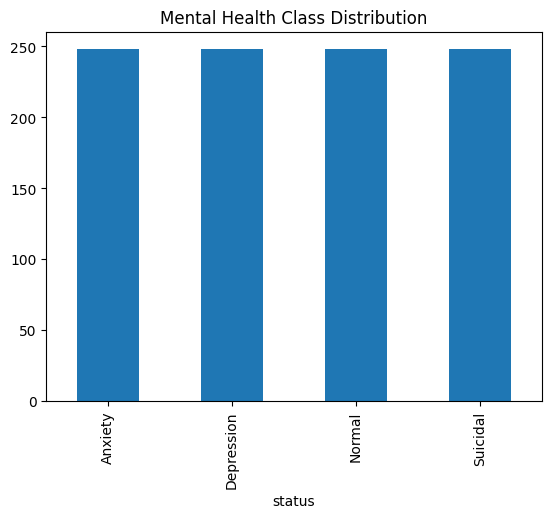

In [5]:
import matplotlib.pyplot as plt

df["status"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Mental Health Class Distribution"
)

plt.show()

In [6]:
# import sys
# import os
# 
# sys.path.append(
    # os.path.abspath("..")
# )

import sys
import os

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

print(project_root)

/home/iamdurgeshb/systemSource/repos/MentalHealthAI


In [7]:
import importlib

import preprocessing.clean_text

importlib.reload(
    preprocessing.clean_text
)

from preprocessing.clean_text import clean_text

In [8]:
df["clean_text"]=df["text"].apply(
    clean_text
)

In [9]:
df[
    ["text","clean_text"]
].head(10)

,text,clean_text
0,i don't understand whats wrong with me. i don'...,understand wrong freak lay bed happen keep tea...
1,usually when i have anxiety just chatting with...,anxiety chat need start feel well anxiety bad ...
2,"well, i've had anxiety and panic syndrome for ...",anxiety panic syndrome year start school heart...
3,"for the most minimal of things, like standing ...",minimal stand someone way moment notice charac...
4,i stay away from family and live with my roomm...,stay family live roommate game fuckin time hap...
5,"i'm very ecstatic, i got a job that literally ...",ecstatic get job fit anxiety family member min...
6,"i've been feeling anxious today, but it's alwa...",feel anxious good reminder fear anxious feelin...
7,i quit my job today. it was fucking terrible. ...,quit job fuck terrible quit bad time work try ...
8,after months of being stuck in a loop of stayi...,month stick loop stay indoor step comfort zone...
9,i’m at a resort with my friends and their pare...,resort friend parent friend bar crowd disco ar...


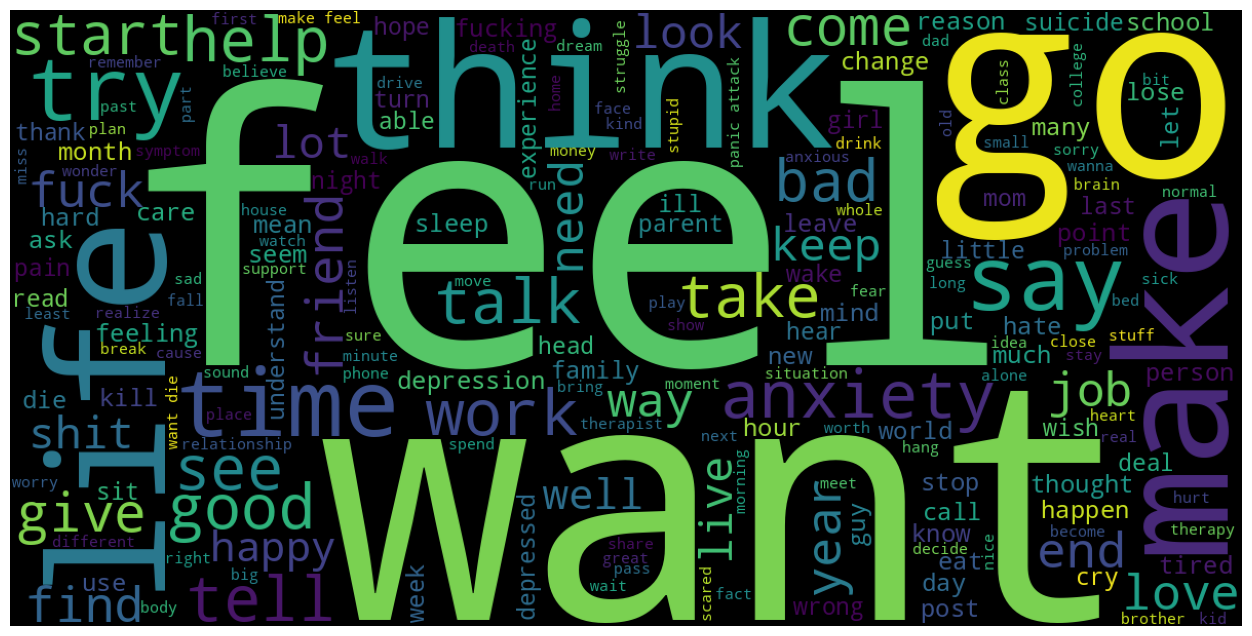

In [10]:
## create word cloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

text=" ".join(
    df["clean_text"]
)

wordcloud=WordCloud(
    width=1200,
    height=600,
    background_color="black"
).generate(text)

plt.figure(figsize=(16,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

In [11]:
df.to_csv(
    "../data/processed/cleaned_data.csv",
    index=False
)

In [12]:
## TEST TF-IDF 

from feature_engineering.tfidf_features import (
    TfidfFeatureExtractor
)

extractor=TfidfFeatureExtractor()

X=extractor.fit_transform(
    df["clean_text"]
)

print(
    X.shape
)

(992, 5000)


In [13]:
# Data inspection 

print(df.shape)

print(
    df["clean_text"].isnull().sum()
)

print(
    (df["clean_text"]=="").sum()
)

(992, 3)
0
0


In [14]:
## Save TF-IDF vectorizer

extractor.save(
    "../models/trained/tfidf.pkl"
)

print(
    "Vectorizer saved successfully"
)

Vectorizer saved successfully


In [15]:
## Test emotion detector

from feature_engineering.emotion_features import (
    detect_emotions
)

sample = """
I feel hopeless and lonely
"""

detect_emotions(sample)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

{'sadness': 0.988,
 'neutral': 0.005,
 'fear': 0.002,
 'disgust': 0.002,
 'surprise': 0.001,
 'joy': 0.001,
 'anger': 0.001}

In [16]:
import sys
import os
import importlib

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

import feature_engineering.critical_detector

importlib.reload(
    feature_engineering.critical_detector
)

print("Reload successful")

Reload successful


In [17]:
## Test detector directly

from feature_engineering.critical_detector import (
    detect_critical
)

sample="""
I want to disappear.
No reason to live.
"""

print(
    detect_critical(sample)
)

['want to disappear', 'no reason to live']


In [18]:
import importlib

import feature_engineering.sentiment_features

importlib.reload(
    feature_engineering.sentiment_features
)

print(
    "Sentiment module reloaded"
)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Sentiment module reloaded


In [20]:
## testing  sentiment separately

from feature_engineering.sentiment_features import (
    get_sentiment
)

sample = """
I feel hopeless and lonely
"""

print(
    get_sentiment(sample)
)

{'label': 'NEGATIVE', 'score': 1.0}


In [21]:
## Testing Risk Score Engine

from models.risk_engine import (
    calculate_risk
)

sample="""
I want to disappear.
No reason to live.
I am done with everything.
"""

result=calculate_risk(
    sample
)

result

{'risk_score': 100,
 'risk_level': 'HIGH',
 'sentiment': {'label': 'NEGATIVE', 'score': 0.999},
 'emotions': {'sadness': 0.862,
  'anger': 0.065,
  'fear': 0.028,
  'neutral': 0.023,
  'disgust': 0.018,
  'joy': 0.002,
  'surprise': 0.002},
 'critical_matches': ['want to disappear',
  'no reason to live',
  'done with everything']}

In [23]:
import pandas as pd

df = pd.read_csv(
    "/home/iamdurgeshb/systemSource/repos/MentalHealthAI/data/raw/mental_health.csv"
)

print(df["status"].value_counts())

status
Anxiety       248
Depression    248
Normal        248
Suicidal      248
Name: count, dtype: int64
